# 16 — Jacobian-Based Inverse Kinematics for a 3-Link Arm

**Section:** Manipulation · **Mirrors MATLAB:** *Inverse Kinematics with Spatial Constraints*

For arms with more joints than task DOFs (or no closed-form solution), we use **damped least-squares** numerical IK:

$$\Delta\theta = J^T (J J^T + \lambda^2 I)^{-1} \Delta x$$

The damping $\lambda$ keeps the update bounded near singularities.

## Intuition — what's actually going on?

Notebook 07 had a closed-form IK for a 2-link arm — solve some triangle math, done. But for a 3-link arm, or any real industrial robot (6+ joints in 3D), there's no closed form. We need **numerical IK**.

The idea is iterative: start with some guess of the joint angles. Compute where the hand currently is. If it's not where we want it, take a *small step* in joint space in the direction that will move the hand toward the target. Repeat.

The "direction in joint space" is the **Jacobian transpose** — the Jacobian `J` is the matrix that relates small joint motions to hand motions, so `J^T` does the reverse mapping. Pure J-transpose can oscillate, so we use **damped least squares**: $J^T (JJ^T + \lambda^2 I)^{-1}$. The damping $\lambda$ acts like an "energy cost" that prevents huge updates, especially near *singularities* (configurations where the arm loses a degree of freedom and J becomes ill-conditioned).

This is how every modern robot arm computes IK in real time. The trade-off: numerical IK converges to *a* solution near your initial guess, not necessarily the globally optimal one — initialization matters.

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| Cumulative angle for link $i$: $\phi_i = \sum_{k \le i} 	heta_k$ | accumulated via `a += theta[i]` in `fk_all` |
| End-effector position $p = \sum_i L_i(\cos\phi_i, \sin\phi_i)$ | `pts[-1] + np.array([l[i]*np.cos(a), l[i]*np.sin(a)])` |
| Jacobian column $i$: $z 	imes (p - p_i)$ where $z = \hat e_z$ | `J[0,i] = -r[1]; J[1,i] = r[0]` with `r = end - pts[i]` |
| Error $\Delta x = x^* - p$ | `err = target - end` |
| Damped least-squares $\Delta	heta = J^T(JJ^T + \lambda^2 I)^{-1}\Delta x$ | `dtheta = J.T @ np.linalg.inv(J @ J.T + lam**2 * np.eye(2)) @ err` |
| Gradient step $	heta \leftarrow 	heta + lpha\Delta	heta$ | `theta = theta + step * dtheta` |
| Convergence test $\|\Delta x\| < 	au$ | `if np.linalg.norm(err) < tol: break` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

l = [1.0, 1.0, 0.8]


def fk_all(theta):
    pts = [np.array([0.0, 0.0])]
    a = 0.0
    for i in range(3):
        a += theta[i]
        pts.append(pts[-1] + np.array([l[i] * np.cos(a), l[i] * np.sin(a)]))
    return np.array(pts)


def jacobian(theta):
    pts = fk_all(theta)
    end = pts[-1]
    J = np.zeros((2, 3))
    for i in range(3):
        r = end - pts[i]
        J[0, i] = -r[1]
        J[1, i] =  r[0]
    return J


def numerical_ik(target, theta_init, max_iter=200, tol=1e-4, lam=0.05, step=0.4):
    theta = theta_init.copy()
    for _ in range(max_iter):
        end = fk_all(theta)[-1]
        err = target - end
        if np.linalg.norm(err) < tol:
            break
        J = jacobian(theta)
        dtheta = J.T @ np.linalg.inv(J @ J.T + lam ** 2 * np.eye(2)) @ err
        theta = theta + step * dtheta
    return theta, np.linalg.norm(err)


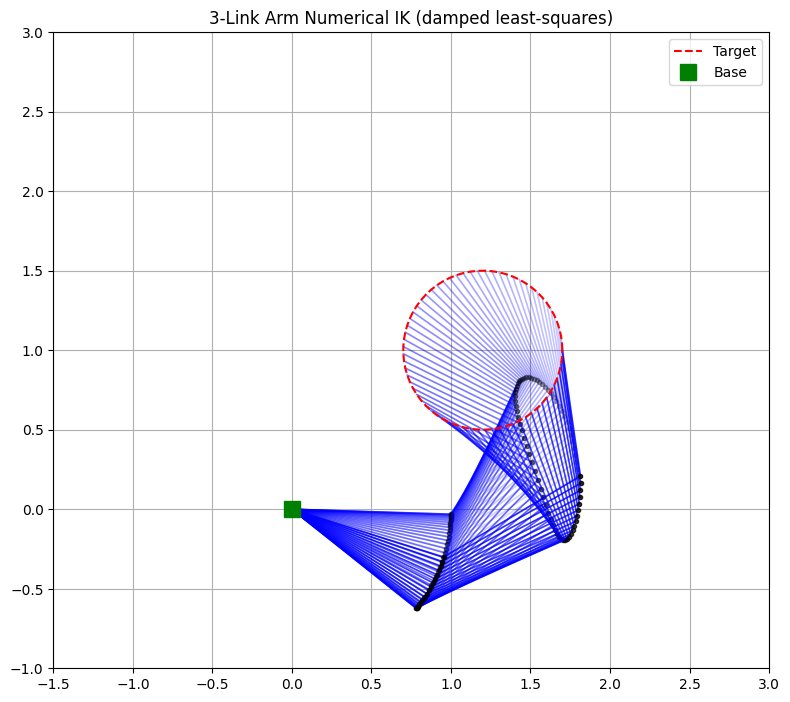

In [2]:
# Trace a target trajectory
N = 70
phi = np.linspace(0, 2 * np.pi, N)
targets = np.column_stack([1.2 + 0.5 * np.cos(phi), 1.0 + 0.5 * np.sin(phi)])

theta = np.array([0.4, 0.4, 0.4])
arm_log = []
for tgt in targets:
    theta, _ = numerical_ik(tgt, theta)
    arm_log.append(fk_all(theta))

fig, ax = plt.subplots(figsize=(8, 8))
for k, pts in enumerate(arm_log):
    a = 0.15 + 0.7 * (k / N)
    ax.plot(pts[:, 0], pts[:, 1], 'b-', alpha=a, lw=1.2)
    ax.plot(pts[1:-1, 0], pts[1:-1, 1], 'ko', ms=3, alpha=a)
ax.plot(targets[:, 0], targets[:, 1], 'r--', lw=1.5, label='Target')
ax.plot(0, 0, 'gs', ms=12, label='Base')
ax.set_xlim(-1.5, 3); ax.set_ylim(-1, 3)
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_title('3-Link Arm Numerical IK (damped least-squares)')
plt.tight_layout()
plt.show()


## References & rigor notes

**Singularity handling.** The damping $\lambda$ in $J^T(JJ^T + \lambda^2 I)^{-1}$ regularizes the inverse near rank-deficient $J$ (singular configurations). Without damping, $JJ^T$ becomes ill-conditioned and the step size blows up. Trade-off: large $\lambda$ → more robust but slower convergence; small $\lambda$ → faster but unstable near singularities.

**Convergence rate.** DLS with fixed $\lambda > 0$ converges *linearly* (it is Levenberg-Marquardt with constant damping, not pure Newton). As $\lambda \to 0$ the rate approaches quadratic (Gauss-Newton) but breaks down near singularities. Production LM adapts $\lambda$ via Marquardt's trust-region rule: shrink $\lambda$ when the step decreases cost (more Newton-like), grow $\lambda$ when it doesn't (more gradient-like). Globally convergent only to *a* local minimum — initialization matters.

**Code remark.** The `step = 0.4` factor in the update is a backstep / line-search multiplier on top of the already-damped DLS step (i.e. double damping). Production LM uses raw DLS step (`step = 1.0`) plus trust-region $\lambda$ adaptation.

**Complexity per iteration.** $O(n^2 \cdot m + m^3)$ where $n$ is joint count and $m$ is task-space dimension. For small arms ($n \le 7$, $m \le 6$) negligible; one iteration runs in microseconds.

**References.**
- Buss, S. R. (2009). *Introduction to inverse kinematics with Jacobian transpose, pseudoinverse and damped least squares methods*. UCSD lecture notes.
- Nakamura, Y., & Hanafusa, H. (1986). *Inverse kinematic solutions with singularity robustness for robot manipulator control*. ASME J. Dyn. Sys., Meas., Control, 108(3).
- Wampler, C. W. (1986). *Manipulator inverse kinematic solutions based on vector formulations and damped least-squares methods*. IEEE Trans. Sys., Man, Cyber., 16(1).
